In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Carga desde un archivo .csv sin indice
bitacora= pd.read_csv('Analisis GAC Full7agosto 2026(Bitacora de Piso).csv') 

In [3]:
#Verificamos información del DataFrame
bitacora.info()

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 30 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Fecha                                       198 non-null    str    
 1   Nombre Cliente                              197 non-null    str    
 2   Telefono                                    0 non-null      float64
 3   Asesor                                      196 non-null    str    
 4   Esatus Lead                                 197 non-null    str    
 5   PDM                                         234 non-null    bool   
 6   SDC                                         216 non-null    object 
 7   Estatus de SDC                              2 non-null      str    
 8   Venta                                       216 non-null    object 
 9   Temperatura                                 10 non-null     str    
 10  Inter Gerente            

In [4]:
#Imprimo los primeros 5 registro del dataframe
bitacora.head()

,Fecha,Nombre Cliente,Telefono,Asesor,Esatus Lead,PDM,SDC,Estatus de SDC,Venta,Temperatura,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,04/01/2025,Ubaldo Cruz Hernandez,NaN,Aurelio,Activo,True,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,04/01/2025,Olivia Cabello,NaN,Pedro,Activo,False,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,04/02/2025,Ana Laura Espinoza,NaN,Mauricio,Activo,True,True,Analisis,True,Lead Interes Alto,...,NaN,NaN,NaN,NaN,NaN,NaN,Items,Items,items,items
3,04/02/2025,Elvis Sanchez,NaN,Aurelio,Activo,False,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,Aurelio,Activo,Aprobada,Lead Interes Medio
4,04/03/2025,Ariel Fernando López,NaN,Alan,Activo,True,False,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Pedro,Cerrado,Condicionada,Lead InteresBajo


Bitácora de Piso — ¿Por que no hubo intervencion del Gerente?

In [6]:
# Extraigo la pregunta abierta
Pregunta_intervencion = bitacora[
    ["¿Por que no hubo intervencion del Gerente?"]
].copy()

# Elimino las respuestas vacías
Pregunta_intervencion = Pregunta_intervencion.dropna()

Pregunta_intervencion

,¿Por que no hubo intervencion del Gerente?
0,"Sí hubo interacción del gerente, los cliente s..."
1,Sí hubo intervención del Gerente. Converse con...
2,Sí hubo intervención del gerente en las dos vi...
3,"Sí hubo intervención y me comento su estatus, ..."
6,"Sí hubo intervención, lo perfile a emzoom vers..."
13,Sí hubo intervención del Gerente. El cliente m...
25,Hice llamada al cliente de seguimiento para da...
34,La primera visita fue en días de descanso pero...
35,Sí hubo intervención del Gerente. El cliente e...
67,"Sí hubo intervención con el gerente de ventas,..."


In [7]:
Pregunta_intervencion["Caracteristica"] = "Otro"

In [9]:
Pregunta_intervencion.loc[

    Pregunta_intervencion["¿Por que no hubo intervencion del Gerente?"]
    .str.contains(
        "sí hubo intervención|si hubo intervención|sí hubo interacción|"
        "si hubo interacción|intervención con el gerente",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Sí hubo intervención"

In [10]:
Pregunta_intervencion.loc[

    Pregunta_intervencion["¿Por que no hubo intervencion del Gerente?"]
    .str.contains(
        "llamada|seguimiento|conocer experiencia|estatus",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Seguimiento posterior"

In [11]:
Pregunta_intervencion.loc[

    Pregunta_intervencion["¿Por que no hubo intervencion del Gerente?"]
    .str.contains(
        "descanso|vacaciones|no se encontraba|ausente",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Gerente no disponible"

In [12]:
Pregunta_intervencion.loc[

    Pregunta_intervencion["¿Por que no hubo intervencion del Gerente?"]
    .str.contains(
        "no tienen la intención de compra|no tiene intención|"
        "acercandose a la marca|acercándose a la marca",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Sin intención inmediata de compra"

In [13]:
Pregunta_intervencion.loc[

    Pregunta_intervencion["¿Por que no hubo intervencion del Gerente?"]
    .str.contains(
        "opciones|indeciso|incesiso|buscaba algo pequeño|"
        "menor valor|buró|buro",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Cliente evaluando opciones"

In [14]:
Pregunta_intervencion.loc[

    Pregunta_intervencion["¿Por que no hubo intervencion del Gerente?"]
    .str.contains(
        "no quizo dejar ningún dato|no quiso dejar ningún dato|"
        "no quiso dejar datos",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Cliente no proporciona datos"

In [15]:
Pregunta_intervencion

,¿Por que no hubo intervencion del Gerente?,Caracteristica
0,"Sí hubo interacción del gerente, los cliente s...",Sin intención inmediata de compra
1,Sí hubo intervención del Gerente. Converse con...,Sí hubo intervención
2,Sí hubo intervención del gerente en las dos vi...,Cliente evaluando opciones
3,"Sí hubo intervención y me comento su estatus, ...",Sin intención inmediata de compra
6,"Sí hubo intervención, lo perfile a emzoom vers...",Sí hubo intervención
13,Sí hubo intervención del Gerente. El cliente m...,Cliente evaluando opciones
25,Hice llamada al cliente de seguimiento para da...,Seguimiento posterior
34,La primera visita fue en días de descanso pero...,Gerente no disponible
35,Sí hubo intervención del Gerente. El cliente e...,Sí hubo intervención
67,"Sí hubo intervención con el gerente de ventas,...",Cliente no proporciona datos


In [16]:
Pregunta_intervencion[
    Pregunta_intervencion["Caracteristica"] == "Otro"
]

,¿Por que no hubo intervencion del Gerente?,Caracteristica


In [17]:
Tabla_gerente = (

    Pregunta_intervencion["Caracteristica"]
    .value_counts()
    .reset_index()

)

Tabla_gerente

,Caracteristica,count
0,Sí hubo intervención,3
1,Sin intención inmediata de compra,2
2,Cliente evaluando opciones,2
3,Gerente no disponible,2
4,Seguimiento posterior,1
5,Cliente no proporciona datos,1


In [19]:
Filtro1 = Tabla_gerente[
    Tabla_gerente["count"] > 1
]

Filtro1

,Caracteristica,count
0,Sí hubo intervención,3
1,Sin intención inmediata de compra,2
2,Cliente evaluando opciones,2
3,Gerente no disponible,2


In [20]:
Filtro_index1 = Filtro1.set_index(
    "Caracteristica"
)

Filtro_index1

,count
Caracteristica,
Sí hubo intervención,3
Sin intención inmediata de compra,2
Cliente evaluando opciones,2
Gerente no disponible,2


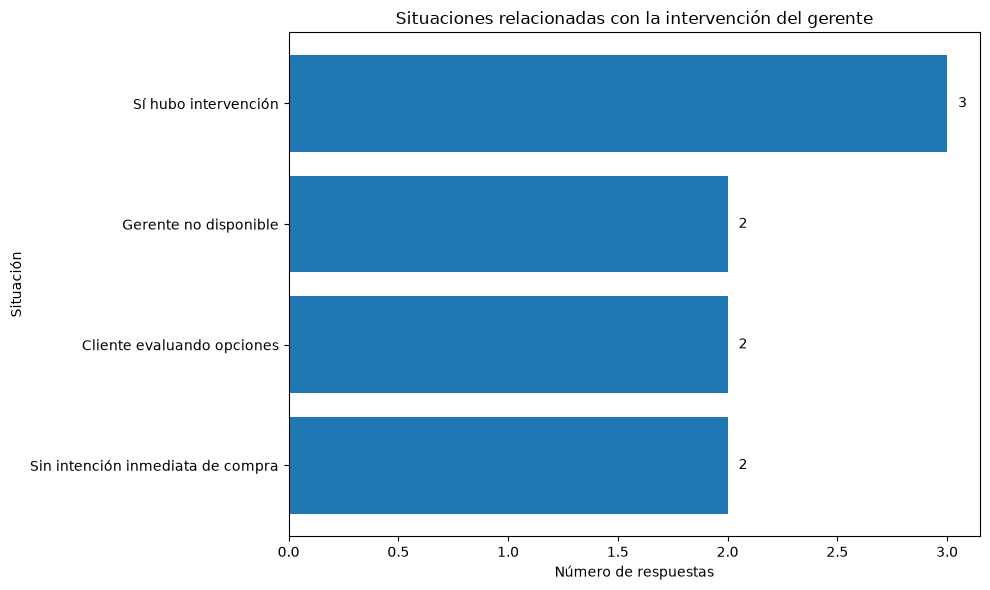

In [21]:

Filtro_index1 = Filtro_index1.sort_values(
    by="count",
    ascending=True
)

plt.figure(figsize=(10, 6))

barras = plt.barh(
    Filtro_index1.index,
    Filtro_index1["count"]
)

for barra in barras:

    ancho = barra.get_width()

    plt.text(
        ancho + 0.05,
        barra.get_y() + barra.get_height()/2,
        int(ancho),
        va="center"
    )

plt.title("Situaciones relacionadas con la intervención del gerente")
plt.xlabel("Número de respuestas")
plt.ylabel("Situación")

plt.tight_layout()
plt.show()